In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/khaledhellmy/brain-breast-tumor/Dataset/Brain scans/No tumor/Test/no598.jpg
/kaggle/input/datasets/khaledhellmy/brain-breast-tumor/Dataset/Brain scans/No tumor/Test/no543.jpg
/kaggle/input/datasets/khaledhellmy/brain-breast-tumor/Dataset/Brain scans/No tumor/Test/no525.jpg
/kaggle/input/datasets/khaledhellmy/brain-breast-tumor/Dataset/Brain scans/No tumor/Test/no596.jpg
/kaggle/input/datasets/khaledhellmy/brain-breast-tumor/Dataset/Brain scans/No tumor/Test/no594.jpg
/kaggle/input/datasets/khaledhellmy/brain-breast-tumor/Dataset/Brain scans/No tumor/Test/no583.jpg
/kaggle/input/datasets/khaledhellmy/brain-breast-tumor/Dataset/Brain scans/No tumor/Test/no544.jpg
/kaggle/input/datasets/khaledhellmy/brain-breast-tumor/Dataset/Brain scans/No tumor/Test/no538.jpg
/kaggle/input/datasets/khaledhellmy/brain-breast-tumor/Dataset/Brain scans/No tumor/Test/no554.jpg
/kaggle/input/datasets/khaledhellmy/brain-breast-tumor/Dataset/Brain scans/No tumor/Test/no578.jpg
/kaggle/in

In [3]:
import pandas as pd
import os

base_paths = [
    ("/kaggle/input/datasets/khaledhellmy/brain-breast-tumor/Dataset/Brain scans/No tumor/Train", "No tumor", "Train"),
    ("/kaggle/input/datasets/khaledhellmy/brain-breast-tumor/Dataset/Brain scans/No tumor/Test", "No tumor", "Test"),
    ("/kaggle/input/datasets/khaledhellmy/brain-breast-tumor/Dataset/Brain scans/Tumor/TRAIN", "Tumor", "Train"),
    ("/kaggle/input/datasets/khaledhellmy/brain-breast-tumor/Dataset/Brain scans/Tumor/TEST", "Tumor", "Test"),
    ("/kaggle/input/datasets/khaledhellmy/brain-breast-tumor/Dataset/Breast scans/benign/Train", "benign", "Train"),
    ("/kaggle/input/datasets/khaledhellmy/brain-breast-tumor/Dataset/Breast scans/benign/Test", "benign" , "Test"),
    ("/kaggle/input/datasets/khaledhellmy/brain-breast-tumor/Dataset/Breast scans/malignant/Train", "malignant", "Train"),
    ("/kaggle/input/datasets/khaledhellmy/brain-breast-tumor/Dataset/Breast scans/malignant/Test", "malignant", "Test"),
    ("/kaggle/input/datasets/khaledhellmy/brain-breast-tumor/Dataset/Breast scans/normal/Train", "normal", "Train"),
    ("/kaggle/input/datasets/khaledhellmy/brain-breast-tumor/Dataset/Breast scans/normal/Test", "normal", "Test")
]

def collect_image_data():
    image_paths = []
    labels = []
    splits = []
    for path, label, split in base_paths:
        if not os.path.exists(path):
            print(f"Warning: Directory {path} does not exist.")
            continue
        for img_name in os.listdir(path):
            img_path = os.path.join(path, img_name)
            if os.path.isfile(img_path) and img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
                image_paths.append(img_path)
                labels.append(label)
                splits.append(split)
    return image_paths, labels, splits

image_paths, labels, splits = collect_image_data()

df = pd.DataFrame({
    'Image_Path': image_paths,
    'Label': labels,
    'Split': splits
})

In [4]:
df


,Image_Path,Label,Split
0,/kaggle/input/datasets/khaledhellmy/brain-brea...,No tumor,Train
1,/kaggle/input/datasets/khaledhellmy/brain-brea...,No tumor,Train
2,/kaggle/input/datasets/khaledhellmy/brain-brea...,No tumor,Train
3,/kaggle/input/datasets/khaledhellmy/brain-brea...,No tumor,Train
4,/kaggle/input/datasets/khaledhellmy/brain-brea...,No tumor,Train
...,...,...,...
2640,/kaggle/input/datasets/khaledhellmy/brain-brea...,normal,Test
2641,/kaggle/input/datasets/khaledhellmy/brain-brea...,normal,Test
2642,/kaggle/input/datasets/khaledhellmy/brain-brea...,normal,Test
2643,/kaggle/input/datasets/khaledhellmy/brain-brea...,normal,Test


EDA - Exploratory Data Analysis

In [5]:
df.shape


(2645, 3)

In [6]:
df.columns


Index(['Image_Path', 'Label', 'Split'], dtype='object')

In [7]:
df.duplicated().sum()


np.int64(0)

In [8]:
df.isnull().sum()

Image_Path    0
Label         0
Split         0
dtype: int64

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2645 entries, 0 to 2644
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Image_Path  2645 non-null   object
 1   Label       2645 non-null   object
 2   Split       2645 non-null   object
dtypes: object(3)
memory usage: 62.1+ KB


In [10]:
df["Label"].unique()

array(['No tumor', 'Tumor', 'benign', 'malignant', 'normal'], dtype=object)

'No tumor', 'Tumor', 'benign', 'malignant', 'normal'

MULTI CLASS CLASSIFICATION

CHECK COUNTS OF DATA

In [11]:
df['Label'].value_counts()

Label
benign       891
No tumor     601
Tumor        600
malignant    420
normal       133
Name: count, dtype: int64

/tmp/ipykernel_55/1046586542.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Label", palette="viridis", ax=ax)


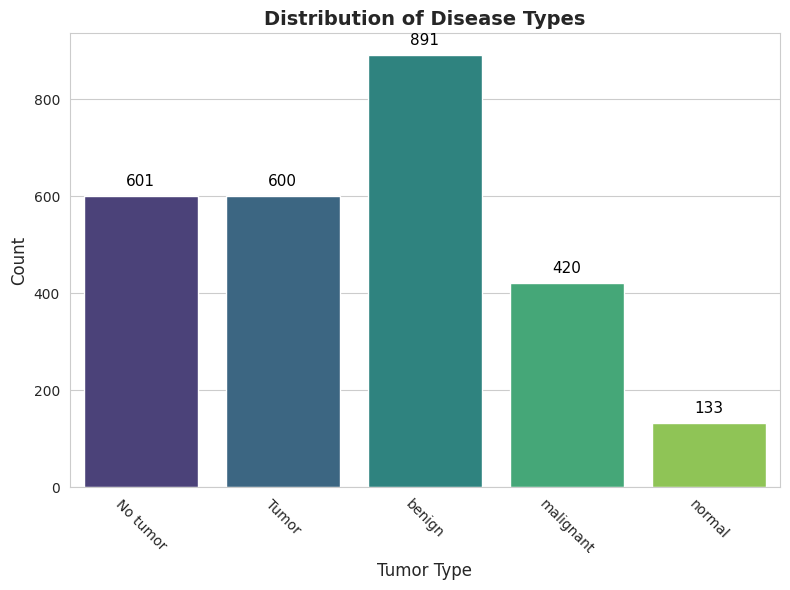

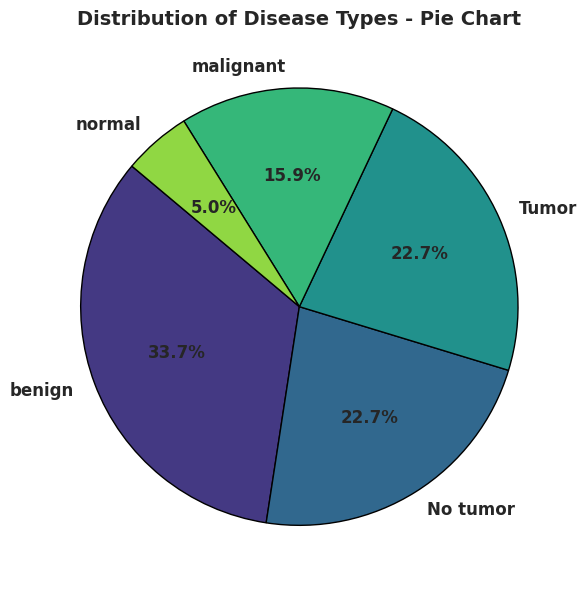

In [12]:

import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

fig, ax = plt.subplots(figsize=(8, 6))
sns.countplot(data=df, x="Label", palette="viridis", ax=ax)
ax.set_title("Distribution of Disease Types", fontsize=14, fontweight='bold')
ax.set_xlabel("Tumor Type", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=11, color='black', 
                xytext=(0, 5), textcoords='offset points')
plt.xticks(rotation=-45)
plt.tight_layout()
plt.show()

label_counts = df["Label"].value_counts()
fig, ax = plt.subplots(figsize=(8, 6))
colors = sns.color_palette("viridis", len(label_counts))
ax.pie(label_counts, labels=label_counts.index, autopct='%1.1f%%', 
       startangle=140, colors=colors, textprops={'fontsize': 12, 'weight': 'bold'},
       wedgeprops={'edgecolor': 'black', 'linewidth': 1})
ax.set_title("Distribution of Disease Types - Pie Chart", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

VISUALIZE THE IMAGES

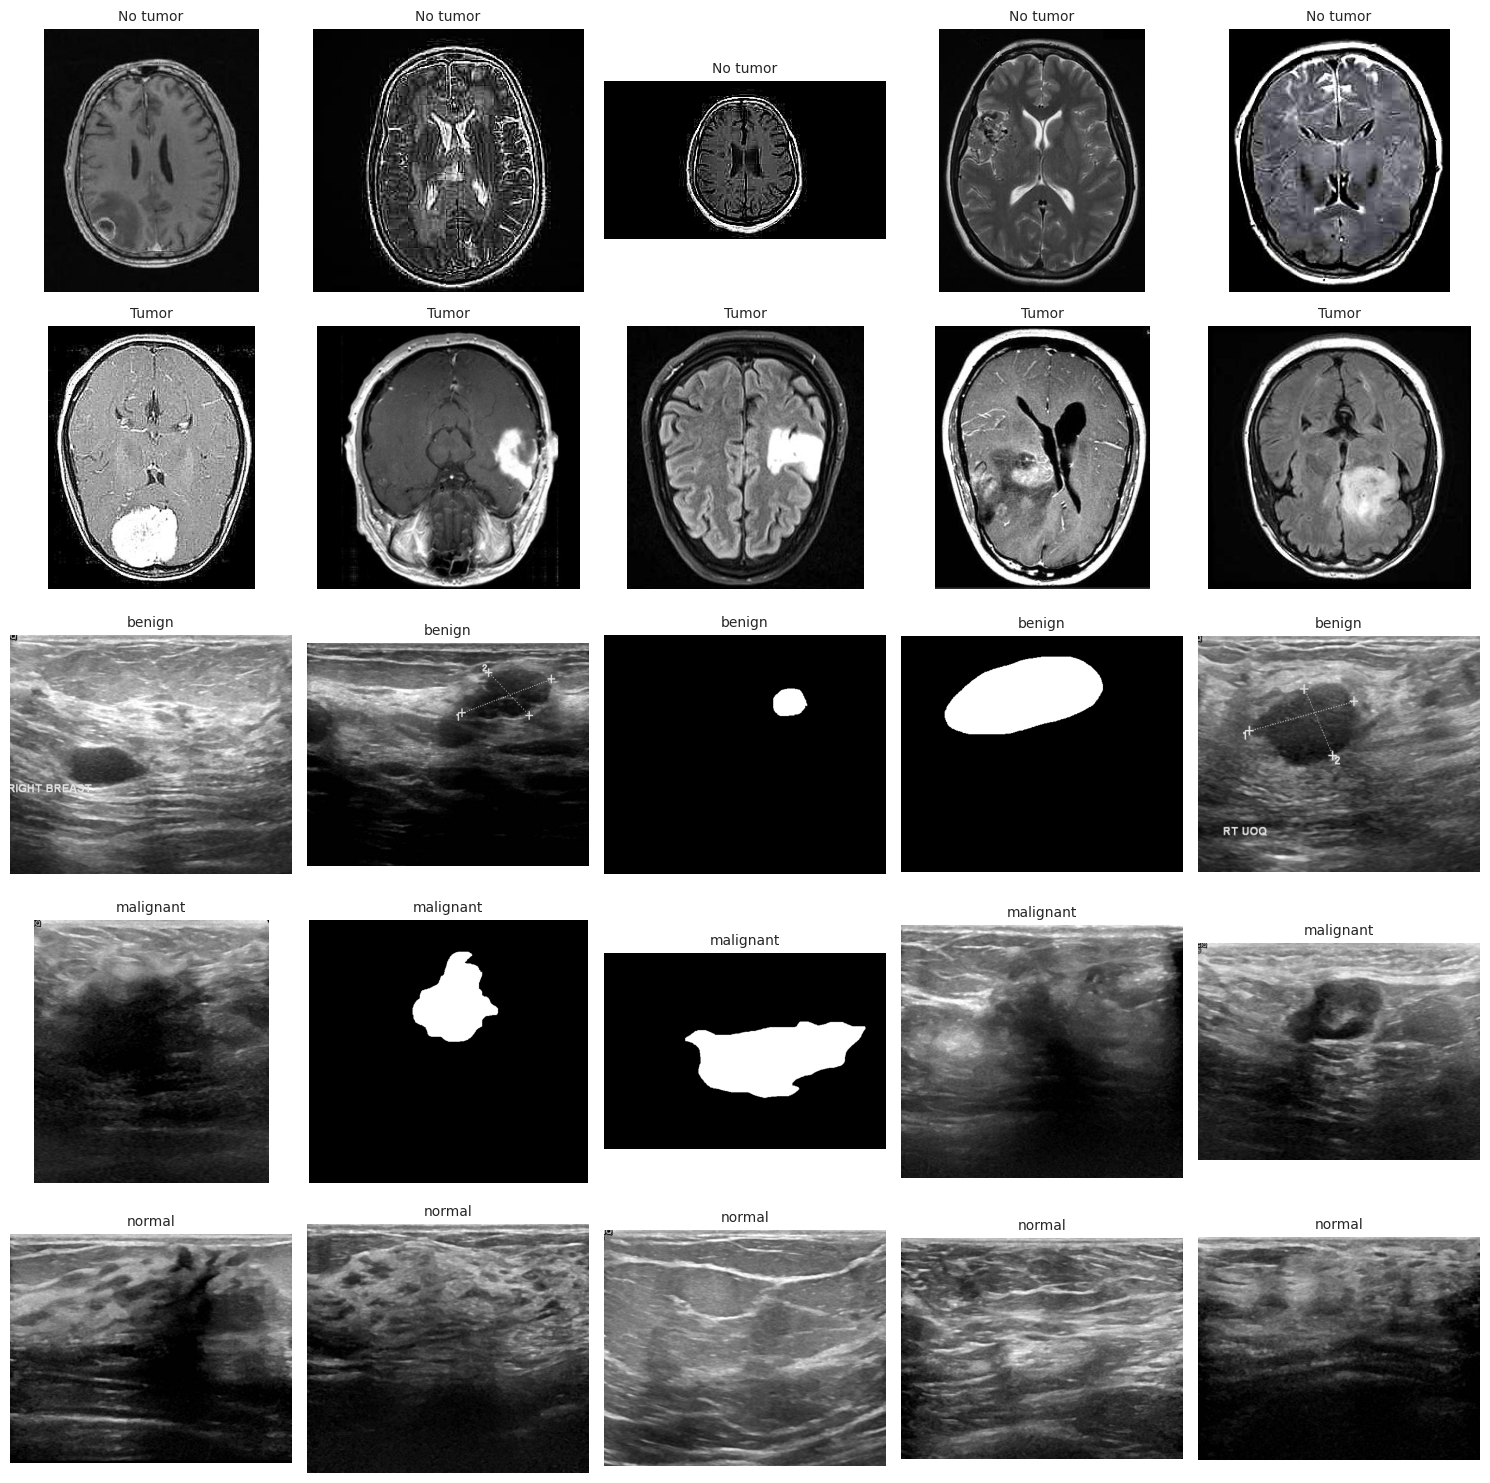

In [13]:

import cv2

categories = df['Label'].unique()

n_cols = 5
n_rows = len(categories)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3, n_rows * 3))
if n_rows == 1:
    axes = [axes]
else:
    axes = axes.flatten()

plot_idx = 0

for category in categories:
    category_paths = df[df['Label'] == category]['Image_Path'].head(5).tolist()
    
    for img_path in category_paths:
        if plot_idx < len(axes):
            try:
                img = cv2.imread(img_path)
                if img is None:
                    axes[plot_idx].text(0.5, 0.5, 'Image not found', 
                                        ha='center', va='center', transform=axes[plot_idx].transAxes)
                else:
                    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                    axes[plot_idx].imshow(img)
                axes[plot_idx].set_title(category, fontsize=10)
                axes[plot_idx].axis('off')
            except:
                axes[plot_idx].text(0.5, 0.5, 'Error loading', 
                                    ha='center', va='center', transform=axes[plot_idx].transAxes)
            plot_idx += 1
    
    while len(category_paths) < 5 and plot_idx < len(axes):
        axes[plot_idx].text(0.5, 0.5, 'No image', 
                            ha='center', va='center', transform=axes[plot_idx].transAxes)
        axes[plot_idx].set_title(category, fontsize=10)
        axes[plot_idx].axis('off')
        plot_idx += 1

plt.tight_layout()
plt.show()

Balancing the Data 

We want a normal distribution but in above distribution we saw uneven distribution of classes. Ways are :-

Data Augmentation (hflip, blur, sharper) - > To increase the no. of samples
Will be doing Random OverSampling.

In [14]:
from sklearn.utils import resample

categories = df['Label'].unique()

max_count = df['Label'].value_counts().max()

df_balanced = pd.DataFrame()

for category in categories:
    df_category = df[df['Label'] == category]
    df_category_resampled = resample(df_category, 
                                    replace=True, 
                                    n_samples=max_count, 
                                    random_state=42)
    df_balanced = pd.concat([df_balanced, df_category_resampled], ignore_index=True)

df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print(df_balanced['Label'].value_counts())

df = df_balanced

Label
malignant    891
No tumor     891
Tumor        891
normal       891
benign       891
Name: count, dtype: int64


In [15]:
df

,Image_Path,Label,Split
0,/kaggle/input/datasets/khaledhellmy/brain-brea...,malignant,Train
1,/kaggle/input/datasets/khaledhellmy/brain-brea...,No tumor,Train
2,/kaggle/input/datasets/khaledhellmy/brain-brea...,Tumor,Train
3,/kaggle/input/datasets/khaledhellmy/brain-brea...,Tumor,Train
4,/kaggle/input/datasets/khaledhellmy/brain-brea...,normal,Train
...,...,...,...
4450,/kaggle/input/datasets/khaledhellmy/brain-brea...,normal,Train
4451,/kaggle/input/datasets/khaledhellmy/brain-brea...,No tumor,Train
4452,/kaggle/input/datasets/khaledhellmy/brain-brea...,malignant,Train
4453,/kaggle/input/datasets/khaledhellmy/brain-brea...,normal,Train


Model Training

In [16]:

import numpy as np
import cv2 #for image_processing
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split


2026-04-23 14:09:36.677650: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776953376.829622      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776953376.872408      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776953377.216707      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776953377.216754      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776953377.216757      55 computation_placer.cc:177] computation placer alr

In [17]:
IMG_SIZE = 128

def load_images(df):
    X = []
    for path in df["Image_Path"]:
        img = cv2.imread(path)
        img = cv2.resize(img,(IMG_SIZE,IMG_SIZE))
        img = img/255.0
        X.append(img)
    return np.array(X)

In [18]:
X = load_images(df)

# one hot encoding labels
y = pd.get_dummies(df["Label"]).values
label_names = pd.get_dummies(df["Label"]).columns


In [19]:
#train-test split 
X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

In [20]:
print(X_train.shape)
print(y_train.shape)

(3564, 128, 128, 3)
(3564, 5)


In [21]:
from tensorflow.keras.models import Sequential  #for sequential NN
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Flatten,Dense,Dropout  #Dropout to include Regularization in Model Training

In [22]:
cnn_model = Sequential([
    
    Conv2D(32,(3,3),activation='relu',input_shape=(128,128,3)),
    MaxPooling2D(2,2),
    
    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D(2,2),
    
    Conv2D(128,(3,3),activation='relu'),
    MaxPooling2D(2,2),
    
    Flatten(),
    Dense(128,activation='relu'),
    Dropout(0.5),
    
    Dense(len(label_names),activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1776953444.406829      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1776953444.412862      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [23]:
cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,285 (12.61 MB)

 Trainable params: 3,305,285 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [24]:
cnn_history = cnn_model.fit(
    X_train,y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test,y_test)
)

Epoch 1/10


I0000 00:00:1776953454.438996     111 service.cc:152] XLA service 0x7a35b4005b80 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776953454.439048     111 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1776953454.439055     111 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1776953454.785456     111 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-04-23 14:10:56.373554: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-23 14:10:56.522366: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


 10/112 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.3181 - loss: 1.5132

I0000 00:00:1776953458.605856     111 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


109/112 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5311 - loss: 1.0450

2026-04-23 14:11:01.381060: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-23 14:11:01.526547: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


112/112 ━━━━━━━━━━━━━━━━━━━━ 13s 63ms/step - accuracy: 0.5340 - loss: 1.0382 - val_accuracy: 0.7733 - val_loss: 0.5577
Epoch 2/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.7502 - loss: 0.5735 - val_accuracy: 0.8496 - val_loss: 0.4113
Epoch 3/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.8392 - loss: 0.4103 - val_accuracy: 0.9046 - val_loss: 0.2697
Epoch 4/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9072 - loss: 0.2510 - val_accuracy: 0.9248 - val_loss: 0.2387
Epoch 5/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9406 - loss: 0.1657 - val_accuracy: 0.9394 - val_loss: 0.2140
Epoch 6/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9577 - loss: 0.1238 - val_accuracy: 0.9652 - val_loss: 0.1617
Epoch 7/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9629 - loss: 0.0955 - val_accuracy: 0.9484 - val_loss: 0.2072
Epoch 8/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9745 - loss: 0.0758 - val_accuracy: 0.95

In [25]:
cnn_model.save("/kaggle/working/baseline_cnn.keras")
cnn_model.save("/kaggle/working/baseline_cnn.h5")

EVALUATION

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

def evaluate_model(model, history, model_name):
    
    print(f"\n{'='*40}")
    print(f"Evaluating {model_name}")
    print(f"{'='*40}")

    # ------------------ Accuracy & Loss Graph ------------------
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    ax1.plot(history.history['accuracy'], label='Train Accuracy')
    ax1.plot(history.history['val_accuracy'], label='Val Accuracy')
    ax1.set_title(f'{model_name} Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()

    ax2.plot(history.history['loss'], label='Train Loss')
    ax2.plot(history.history['val_loss'], label='Val Loss')
    ax2.set_title(f'{model_name} Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()

    plt.tight_layout()
    plt.show()

    # ------------------ Predictions ------------------
    y_pred = model.predict(X_test, verbose=0)
    y_pred_classes = np.argmax(y_pred, axis=1)
    y_test_classes = np.argmax(y_test, axis=1)

    # ------------------ Confusion Matrix ------------------
    cm = confusion_matrix(y_test_classes, y_pred_classes)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_names,
                yticklabels=label_names)
    
    plt.title(f'{model_name} Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # ------------------ Classification Report ------------------
    print(f"\n{model_name} Classification Report:\n")
    print(classification_report(y_test_classes, y_pred_classes, target_names=label_names))


Evaluating Baseline CNN Model


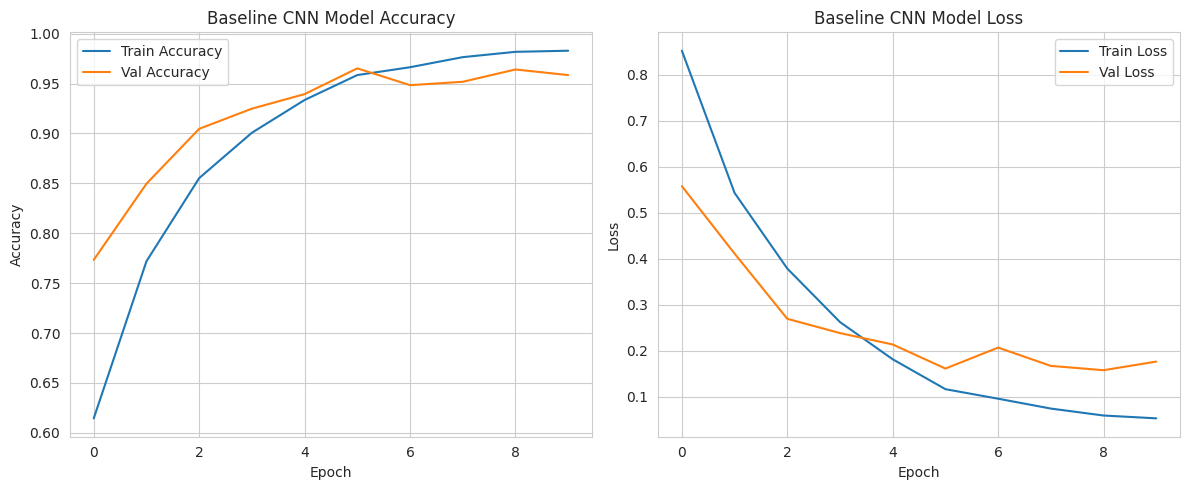

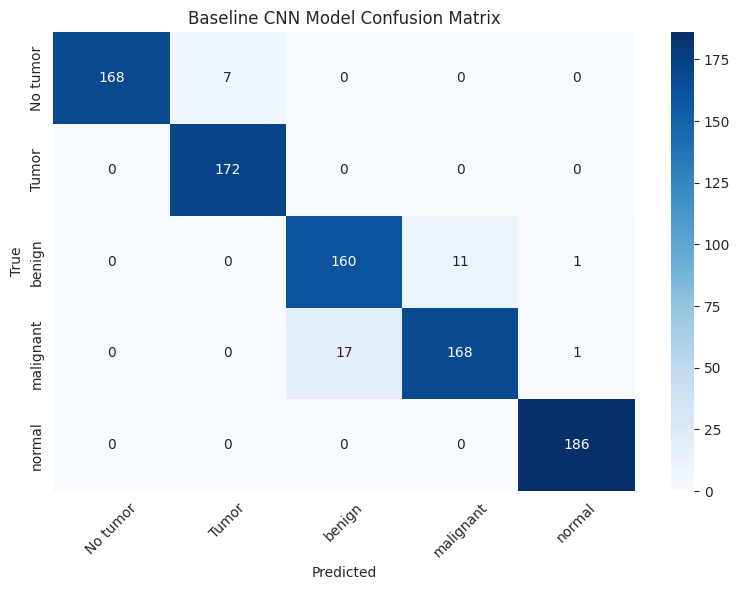


Baseline CNN Model Classification Report:

              precision    recall  f1-score   support

    No tumor       1.00      0.96      0.98       175
       Tumor       0.96      1.00      0.98       172
      benign       0.90      0.93      0.92       172
   malignant       0.94      0.90      0.92       186
      normal       0.99      1.00      0.99       186

    accuracy                           0.96       891
   macro avg       0.96      0.96      0.96       891
weighted avg       0.96      0.96      0.96       891



In [27]:
evaluate_model(cnn_model, cnn_history, "Baseline CNN Model")

RESNET

TRANSFER LEARNING

In [28]:
#RESNET50 TRANSFER LEARNING

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense,Flatten,GlobalAveragePooling2D
from tensorflow.keras.models import Model


In [29]:
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(128,128,3)
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [30]:
# freeze base model
for layer in base_model.layers:
    layer.trainable=False

In [31]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128,activation='relu')(x)
x = Dropout(0.5)(x)

In [32]:
outputs = Dense(len(label_names),activation='softmax')(x)

In [33]:
resnet_model = Model(inputs=base_model.input,outputs=outputs)

In [34]:
resnet_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [35]:
resnet_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 134, 134,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 64, 64,    │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 64, 64,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 64, 64,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 66, 66,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 32, 32,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 32, 32,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 32, 32,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 32, 32,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 32, 32,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 32, 32,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 32, 32,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 32, 32,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 32, 32,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 32, 32,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 32, 32,    │      1,024 │ conv2_block1_3_c

 Total params: 23,850,629 (90.98 MB)

 Trainable params: 262,917 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [36]:
resnet_history = resnet_model.fit(
    X_train,y_train,
    epochs=8,
    batch_size=32,
    validation_data=(X_test,y_test)
)

Epoch 1/8
112/112 ━━━━━━━━━━━━━━━━━━━━ 27s 141ms/step - accuracy: 0.3686 - loss: 1.4546 - val_accuracy: 0.5668 - val_loss: 1.0378
Epoch 2/8
112/112 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - accuracy: 0.5421 - loss: 1.0462 - val_accuracy: 0.5948 - val_loss: 0.8914
Epoch 3/8
112/112 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - accuracy: 0.5961 - loss: 0.9182 - val_accuracy: 0.6622 - val_loss: 0.8005
Epoch 4/8
112/112 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - accuracy: 0.6231 - loss: 0.8528 - val_accuracy: 0.7037 - val_loss: 0.7584
Epoch 5/8
112/112 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - accuracy: 0.6487 - loss: 0.7891 - val_accuracy: 0.6846 - val_loss: 0.7104
Epoch 6/8
112/112 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - accuracy: 0.6551 - loss: 0.7627 - val_accuracy: 0.6914 - val_loss: 0.7117
Epoch 7/8
112/112 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - accuracy: 0.6577 - loss: 0.7598 - val_accuracy: 0.7093 - val_loss: 0.6802
Epoch 8/8
112/112 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - accuracy: 0.6924 - loss: 0.7033 - val_accuracy: 

In [37]:
resnet_model.save("/kaggle/working/resnet_model.keras")
resnet_model.save("/kaggle/working/resnet_model.h5")


Evaluating ResNet50 Model


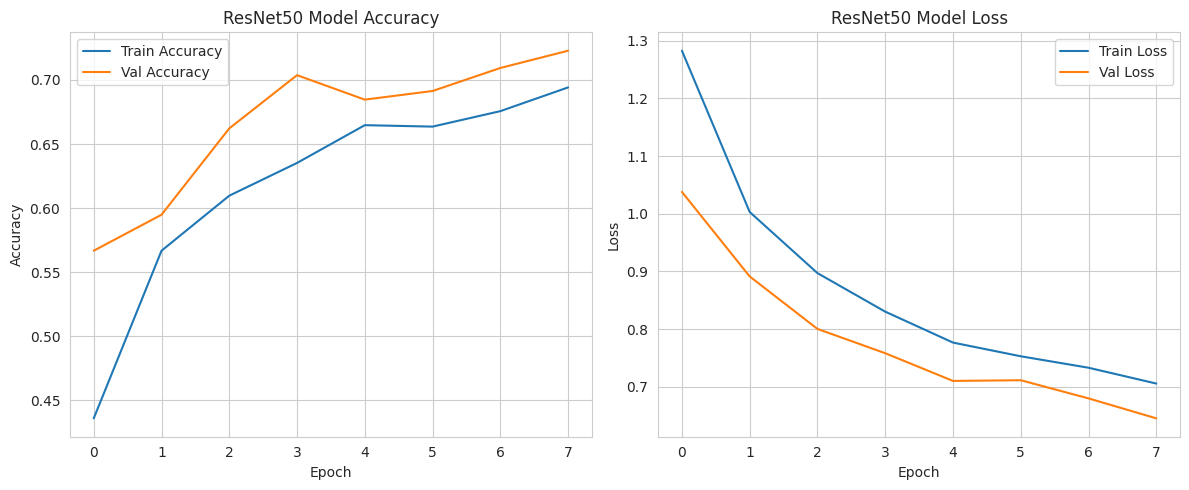

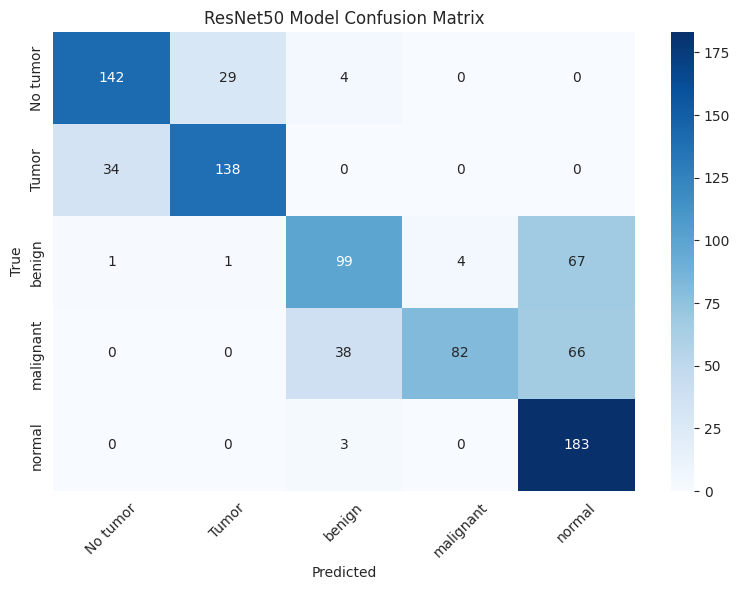


ResNet50 Model Classification Report:

              precision    recall  f1-score   support

    No tumor       0.80      0.81      0.81       175
       Tumor       0.82      0.80      0.81       172
      benign       0.69      0.58      0.63       172
   malignant       0.95      0.44      0.60       186
      normal       0.58      0.98      0.73       186

    accuracy                           0.72       891
   macro avg       0.77      0.72      0.72       891
weighted avg       0.77      0.72      0.71       891



In [38]:
evaluate_model(resnet_model, resnet_history, "ResNet50 Model")

CUSTOM TRIGNOMETRIC FILTER CNN

In [39]:

import tensorflow as tf
from tensorflow.keras.layers import Layer, Input, Dense, Flatten
from tensorflow.keras.models import Model
import cv2
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report


In [40]:
class TrigConv2D(Layer):
    def __init__(self, filters, kernel_size, frequency=1.0, **kwargs):
        super(TrigConv2D, self).__init__(**kwargs)
        self.filters = filters
        self.kernel_size = kernel_size
        self.frequency = frequency

    def build(self, input_shape):
        kernel_shape = (self.kernel_size, self.kernel_size, input_shape[-1], self.filters)
        kernels = []
        for i in range(self.filters):
            x = np.linspace(-1, 1, self.kernel_size)
            y = np.linspace(-1, 1, self.kernel_size)
            x_grid, y_grid = np.meshgrid(x, y)
            if i % 2 == 0:
                kernel = np.sin(self.frequency * (x_grid + y_grid))
            else:
                kernel = np.cos(self.frequency * (x_grid + y_grid))
            kernel = kernel[:, :, np.newaxis, np.newaxis]
            kernel = np.repeat(kernel, input_shape[-1], axis=2)
            kernel = np.repeat(kernel, 1, axis=3)
            kernels.append(kernel)
        self.kernel = tf.constant(np.concatenate(kernels, axis=3), dtype=tf.float32)
        super(TrigConv2D, self).build(input_shape)

    def call(self, inputs):
        return tf.nn.conv2d(inputs, self.kernel, strides=[1, 1, 1, 1], padding='SAME')

In [41]:
def load_and_preprocess_image(image_path, target_size=(128, 128)):
    img = cv2.imread(image_path)
    if img is None:
        return np.zeros((*target_size, 3))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, target_size)
    img = img / 255.0
    return img

In [42]:
image_size = (128, 128)
X = np.array([load_and_preprocess_image(path, image_size) for path in df['Image_Path']])
y = pd.get_dummies(df['Label']).values
label_names = pd.get_dummies(df['Label']).columns


In [43]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [44]:
inputs = Input(shape=(image_size[0], image_size[1], 3))
x = TrigConv2D(filters=16, kernel_size=3, frequency=2.0)(inputs)
x = tf.keras.layers.Activation('relu')(x)
x = tf.keras.layers.MaxPooling2D(pool_size=(2, 2))(x)
x = tf.keras.layers.Conv2D(32, (3, 3), activation='relu')(x)
x = tf.keras.layers.MaxPooling2D(pool_size=(2, 2))(x)
x = Flatten()(x)
x = Dense(64, activation='relu')(x)
outputs = Dense(len(label_names), activation='softmax')(x)

model = Model(inputs, outputs)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [45]:
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test))

Epoch 1/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 6s 33ms/step - accuracy: 0.4915 - loss: 1.9168 - val_accuracy: 0.7722 - val_loss: 0.5178
Epoch 2/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8872 - loss: 0.3306 - val_accuracy: 0.8889 - val_loss: 0.3238
Epoch 3/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9786 - loss: 0.1050 - val_accuracy: 0.9327 - val_loss: 0.2106
Epoch 4/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9879 - loss: 0.0454 - val_accuracy: 0.9450 - val_loss: 0.2006
Epoch 5/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9979 - loss: 0.0132 - val_accuracy: 0.9484 - val_loss: 0.2103
Epoch 6/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9996 - loss: 0.0074 - val_accuracy: 0.9506 - val_loss: 0.2230
Epoch 7/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 1.0000 - loss: 0.0026 - val_accuracy: 0.9125 - val_loss: 0.3456
Epoch 8/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9986 - loss: 0.0079 - val_accuracy: 0

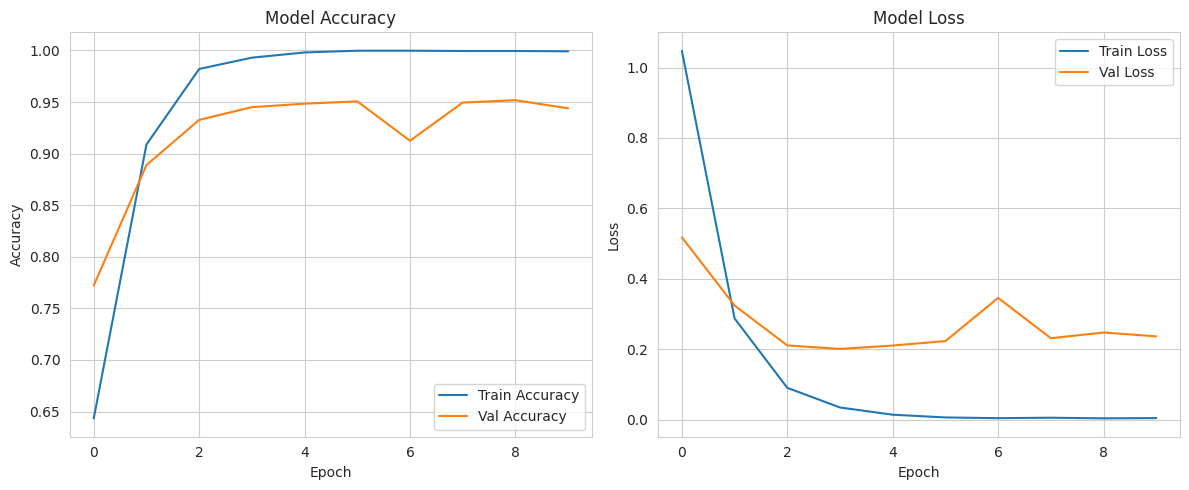

28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step


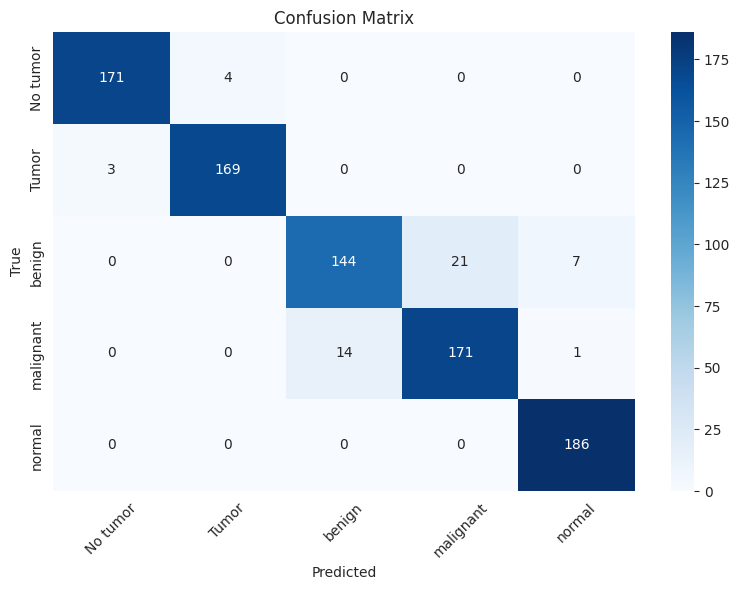


Classification Report:
              precision    recall  f1-score   support

    No tumor       0.98      0.98      0.98       175
       Tumor       0.98      0.98      0.98       172
      benign       0.91      0.84      0.87       172
   malignant       0.89      0.92      0.90       186
      normal       0.96      1.00      0.98       186

    accuracy                           0.94       891
   macro avg       0.94      0.94      0.94       891
weighted avg       0.94      0.94      0.94       891



In [46]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.plot(history.history['accuracy'], label='Train Accuracy')
ax1.plot(history.history['val_accuracy'], label='Val Accuracy')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax2.plot(history.history['loss'], label='Train Loss')
ax2.plot(history.history['val_loss'], label='Val Loss')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
plt.tight_layout()
plt.show()

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_test_classes = np.argmax(y_test, axis=1)
cm = confusion_matrix(y_test_classes, y_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_names, yticklabels=label_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(y_test_classes, y_pred_classes, target_names=label_names))

In [47]:
model.save("/kaggle/working/trig_model.keras")
model.save("/kaggle/working/trig_model.h5")

WRITE A BETTER NEURAL NETWORK SOLVING THE DRAWBACKS OF THIS NEURAL NETWORK


GRAD CAM

In [48]:
#GradCAM implementation 
#Function to generate GradCAM
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

def get_gradcam(model, image, conv2d, pred_index=None):
    
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(conv2d).output, model.output]
    )
    
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(np.array([image]))
        
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
            
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.reduce_max(heatmap)
    return heatmap.numpy()

In [49]:
#Superimpose heatmap on image
def display_gradcam(img, heatmap, alpha=0.4):
    
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    superimposed_img = cv2.addWeighted(img, 1-alpha, heatmap, alpha, 0)
    
    plt.figure(figsize=(6,6))
    plt.imshow(superimposed_img)
    plt.axis('off')
    plt.title("Grad-CAM Visualization")
    plt.show()

In [50]:
#Test GradCAM on sample image
idx = 10   # change index
sample_image = X_test[idx]
true_label = np.argmax(y_test[idx])

pred = model.predict(np.array([sample_image]))
pred_class = np.argmax(pred)

print("True label:", label_names[true_label])
print("Predicted:", label_names[pred_class])


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 482ms/step
True label: benign
Predicted: malignant


In [51]:
heatmap = get_gradcam(model, sample_image, "conv2d")
display_gradcam((sample_image*255).astype("uint8"), heatmap)


ValueError: No such layer: conv2d. Existing layers are: ['input_layer_2', 'trig_conv2d', 'activation', 'max_pooling2d_3', 'conv2d_3', 'max_pooling2d_4', 'flatten_1', 'dense_4', 'dense_5'].